# LDAP

# Import library

In [1]:
# Data manipulation and numerical operations
import numpy as np
import pandas as pd

# Statistical analysis
import scipy.stats as st
from scipy.stats import (
    expon,
    lognorm,
    weibull_min,
    gamma as gamma_dist,
    kstest,
    chisquare,
    wasserstein_distance, 
    ks_2samp, 
)
from scipy.special import gamma
from scipy.spatial.distance import jensenshannon

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator, LogFormatter
import csv

# Read data

### Input Data

In [2]:
# read_data
csv_file_path = "D:\\KULIAH\\SKRIPSI AFI\\DES\\dataset\\CIC-DDoS2019\\LDAP\\ldap_gabung.csv"
df = pd.read_csv(csv_file_path)

D:\Temp\ipykernel_23688\751957799.py:3: DtypeWarning: Columns (7,8,11,12,14,15,16,17,18,19,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


In [3]:
df

,No.,Time,Delta,Src MAC,Dst MAC,Source,Destination,Src Port,Dst Port,Protocol,...,CWR,ECE,FIN,PUSH,RES,RESET,URG,STR,tcp.seq,Source_File
0,1,2018-11-03 10:09:00.565557,NaN,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,870,2908,DNS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_011.csv
1,2,2018-11-03 10:09:00.565558,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,870,2908,DNS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_011.csv
2,3,2018-11-03 10:09:00.565559,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,871,53796,DNS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_011.csv
3,4,2018-11-03 10:09:00.565607,0.000048,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,871,53796,DNS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_011.csv
4,5,2018-11-03 10:09:00.565608,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,648,40660,DNS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_011.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460766,273132,2018-11-03 10:34:11.268572,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,5392.0,27391.0,UDP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_068.csv
9460767,273133,2018-11-03 10:34:11.268621,0.000049,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,5392.0,27391.0,UDP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_068.csv
9460768,273134,2018-11-03 10:34:11.268622,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,5393.0,61344.0,UDP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_068.csv
9460769,273135,2018-11-03 10:34:11.268623,0.000001,Cisco_42:73:e8,Dell_a2:c0:d3,172.16.0.5,192.168.50.4,5393.0,61344.0,UDP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CSV-03-11-2018_068.csv


## Preprocessing data

In [4]:
drop_column = ['Delta', 'Src Port', 'Dst Port', 'ACK', 'SYN', 'ACE', 'AE', 'CWR', 'ECE', 'FIN', 'PUSH', 'RES', 'RESET', 'URG', 'STR', 'tcp.seq', 'Src MAC', 'Dst MAC', 'Protocol', 'Length']
df = df.drop(columns=drop_column)

In [5]:
df

,No.,Time,Source,Destination,Source_File
0,1,2018-11-03 10:09:00.565557,172.16.0.5,192.168.50.4,CSV-03-11-2018_011.csv
1,2,2018-11-03 10:09:00.565558,172.16.0.5,192.168.50.4,CSV-03-11-2018_011.csv
2,3,2018-11-03 10:09:00.565559,172.16.0.5,192.168.50.4,CSV-03-11-2018_011.csv
3,4,2018-11-03 10:09:00.565607,172.16.0.5,192.168.50.4,CSV-03-11-2018_011.csv
4,5,2018-11-03 10:09:00.565608,172.16.0.5,192.168.50.4,CSV-03-11-2018_011.csv
...,...,...,...,...,...
9460766,273132,2018-11-03 10:34:11.268572,172.16.0.5,192.168.50.4,CSV-03-11-2018_068.csv
9460767,273133,2018-11-03 10:34:11.268621,172.16.0.5,192.168.50.4,CSV-03-11-2018_068.csv
9460768,273134,2018-11-03 10:34:11.268622,172.16.0.5,192.168.50.4,CSV-03-11-2018_068.csv
9460769,273135,2018-11-03 10:34:11.268623,172.16.0.5,192.168.50.4,CSV-03-11-2018_068.csv


In [6]:
# Hitung jumlah nilai kosong di setiap kolom
missing = df.isnull().sum()
print(missing)

No.            0
Time           0
Source         0
Destination    0
Source_File    0
dtype: int64


In [7]:
# Urutkan berdasarkan waktu dari paling awal ke paling akhir
df = df.sort_values(by='Time').reset_index(drop=True)

In [8]:
# Ubah kolom Time ke datetime
df['Time'] = pd.to_datetime(
    df['Time'],
    format='%Y-%m-%d %H:%M:%S.%f',
    errors='coerce'
)

# Hapus data yang waktunya gagal terbaca
df = df.dropna(subset=['Time'])

# Ambil data tanggal 12 Januari 2018 jam 12:27:00 sampai 12:37:59
start_time = pd.to_datetime('2018-11-03 10:21:00')
end_time = pd.to_datetime('2018-11-03 10:30:59')

df_filter = df[
    (df['Time'] >= start_time) &
    (df['Time'] <= end_time)
].copy()

# Tambahkan kolom Label
df_filter['Label'] = 'LDAP'

# Urutkan berdasarkan waktu
df_filter = df_filter.sort_values('Time').reset_index(drop=True)

print("Jumlah data hasil filter:", len(df_filter))
print(df_filter)
print(df_filter.tail())

Jumlah data hasil filter: 8759027
            No.                       Time          Source  \
0        474305 2018-11-03 10:21:00.245963    192.168.50.9   
1        474306 2018-11-03 10:21:00.245967    192.168.50.9   
2        474307 2018-11-03 10:21:00.266837  23.194.142.213   
3        474308 2018-11-03 10:21:00.266841  23.194.142.213   
4        474309 2018-11-03 10:21:00.267797  23.194.142.213   
...         ...                        ...             ...   
8759022   45692 2018-11-03 10:30:57.906324    192.168.50.4   
8759023   45693 2018-11-03 10:30:57.906327    192.168.50.4   
8759024   45694 2018-11-03 10:30:58.364604  Cisco_66:a1:18   
8759025   45695 2018-11-03 10:30:58.429689         0.0.0.0   
8759026   45696 2018-11-03 10:30:58.504712  Cisco_66:a1:19   

                   Destination             Source_File Label  
0               23.194.142.213  CSV-03-11-2018_011.csv  LDAP  
1               23.194.142.213  CSV-03-11-2018_011.csv  LDAP  
2                 192.168.50.9  

In [9]:
df_filter.to_csv(
    'ldap_fix.csv',
    index=False
)

In [3]:
# read_data
csv_file_path = "D:\\KULIAH\\SKRIPSI AFI\\DES\\dataset\\CIC-DDoS2019\\LDAP\\ldap_fix.csv"
df = pd.read_csv(csv_file_path)

In [4]:
# Frekuensi pasangan Source–Destination IP
ip_count = (
    df.groupby(['Source', 'Destination', 'Label'])
      .size()
      .reset_index(name='Count')
      .sort_values('Count', ascending=False)
)
display(ip_count)

,Source,Destination,Label,Count
17,172.16.0.5,192.168.50.4,LDAP,8731449
83,192.168.50.4,172.16.0.5,LDAP,1832
152,192.168.50.8,172.217.2.166,LDAP,592
50,172.217.2.166,192.168.50.8,LDAP,538
127,192.168.50.6,4.2.2.4,LDAP,450
...,...,...,...,...
430,MS-NLB-PhysServer-01_01:64:84:00,30:84:00:00:0a:08,LDAP,1
429,MS-NLB-PhysServer-01_01:64:84:00,30:84:00:00:09:f6,LDAP,1
428,MS-NLB-PhysServer-01_01:64:84:00,30:84:00:00:09:86,LDAP,1
426,MS-NLB-PhysServer-01_01:64:84:00,30:84:00:00:09:1b,LDAP,1


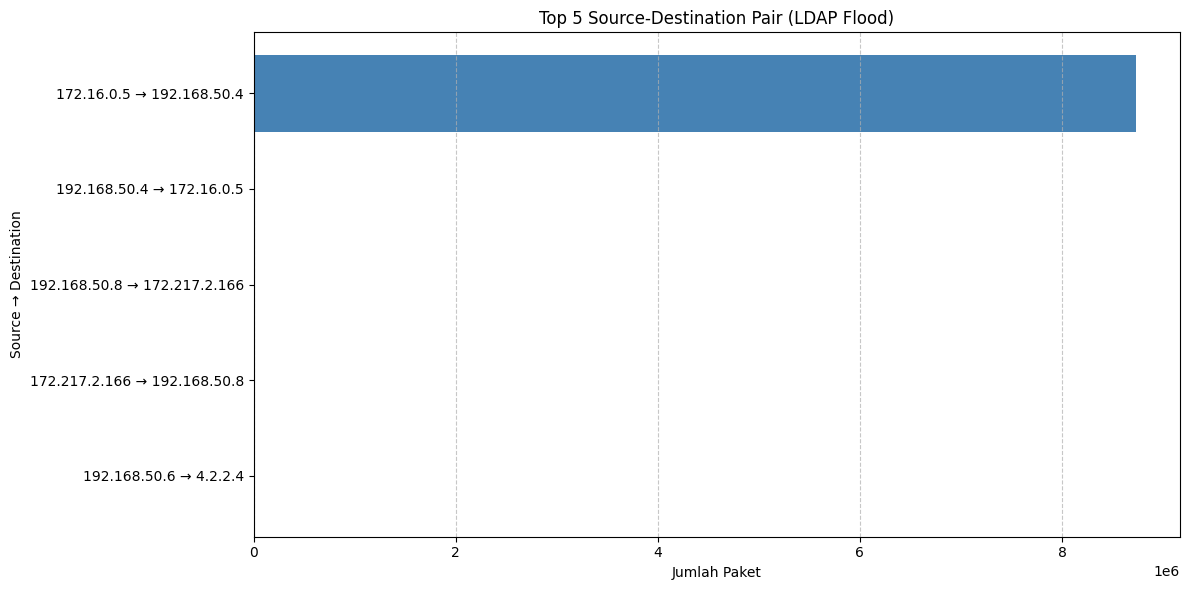

In [5]:
# Ambil top 5 pair
top_ip = ip_count.head(5).copy()

# Gabungkan Source dan Destination menjadi label
top_ip['Pair'] = (
    top_ip['Source'] + ' → ' + top_ip['Destination']
)

# Membuat warna berdasarkan label
colors = []

for label in top_ip['Label']:
    if label.lower() == 'LDAP':
        colors.append('steelblue')
    else:
        colors.append('salmon')

# Plot bar chart
plt.figure(figsize=(12,6))

plt.barh(
    top_ip['Pair'],
    top_ip['Count'],
    color='steelblue'
)

plt.xlabel('Jumlah Paket')
plt.ylabel('Source → Destination')
plt.title('Top 5 Source-Destination Pair (LDAP Flood)')

# Membalik urutan agar terbesar di atas
plt.gca().invert_yaxis()

# Menampilkan grid
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
df_ldap = df[df['Label'] == 'LDAP'].copy()

In [7]:
# Hitung total data
total_data = len(df_ldap)

# Hitung jumlah data per pasangan
pair_percentage = (
    df_ldap
    .groupby(['Source', 'Destination'])
    .size()
    .reset_index(name='Jumlah_Data')
)

# Hitung persentase
pair_percentage['Persentase (%)'] = (
    pair_percentage['Jumlah_Data'] / total_data * 100
)

# Urutkan dari terbesar
pair_percentage = pair_percentage.sort_values(
    'Persentase (%)', ascending=False
)

print(pair_percentage.head(5))

            Source    Destination  Jumlah_Data  Persentase (%)
17      172.16.0.5   192.168.50.4      8731449       99.685148
83    192.168.50.4     172.16.0.5         1832        0.020916
152   192.168.50.8  172.217.2.166          592        0.006759
50   172.217.2.166   192.168.50.8          538        0.006142
127   192.168.50.6        4.2.2.4          450        0.005138


In [7]:
# Urutkan dari yang terbanyak
ip_count = ip_count.sort_values('Count', ascending=False)

# Ambil pasangan terbanyak
top_pair = ip_count.head(1)

print(top_pair)

        Source   Destination Label    Count
17  172.16.0.5  192.168.50.4  LDAP  8731449


In [8]:
# Cari pasangan Source-Destination dengan jumlah data terbanyak
top_pair = (
    df_ldap
    .groupby(['Source', 'Destination'])
    .size()
    .reset_index(name='Packet_Count')
    .sort_values('Packet_Count', ascending=False)
    .head(1)
)

print("Pasangan Source-Destination dengan data terbanyak:")
display(top_pair)

# Ambil hanya data dari pasangan teratas
df_ldap_top = df_ldap.merge(
    top_pair[['Source', 'Destination']],
    on=['Source', 'Destination'],
    how='inner'
)

# Pastikan kolom Time bertipe datetime sebelum menghitung interarrival
df_ldap_top['Time'] = pd.to_datetime(
    df_ldap_top['Time'],
    errors='coerce'
)

# Buang baris yang gagal dikonversi
df_ldap_top = df_ldap_top.dropna(subset=['Time'])

# Urutkan berdasarkan waktu untuk pasangan tersebut
df_ldap_top = df_ldap_top.sort_values('Time')

# Hitung interarrival time khusus pasangan tersebut
df_ldap_top['Interarrival'] = (
    df_ldap_top['Time']
    .diff()
    .dt.total_seconds()
)

# Hapus baris pertama karena tidak punya interarrival sebelumnya
df_ldap_top = df_ldap_top.dropna(subset=['Interarrival'])

# Ambil hanya interarrival positif
df_ldap_top = df_ldap_top[df_ldap_top['Interarrival'] > 0]

print("Interarrival time untuk pasangan Source-Destination dengan data terbanyak:")
display(
    df_ldap_top[['Source', 'Destination', 'Time', 'Interarrival', 'Label']]
)

Pasangan Source-Destination dengan data terbanyak:


,Source,Destination,Packet_Count
17,172.16.0.5,192.168.50.4,8731449


Interarrival time untuk pasangan Source-Destination dengan data terbanyak:


,Source,Destination,Time,Interarrival,Label
1,172.16.0.5,192.168.50.4,2018-11-03 10:21:16.908090,0.000003,LDAP
2,172.16.0.5,192.168.50.4,2018-11-03 10:21:17.412099,0.504009,LDAP
3,172.16.0.5,192.168.50.4,2018-11-03 10:21:17.412102,0.000003,LDAP
4,172.16.0.5,192.168.50.4,2018-11-03 10:21:17.604621,0.192519,LDAP
5,172.16.0.5,192.168.50.4,2018-11-03 10:21:17.604624,0.000003,LDAP
...,...,...,...,...,...
8731444,172.16.0.5,192.168.50.4,2018-11-03 10:30:57.276278,0.000003,LDAP
8731445,172.16.0.5,192.168.50.4,2018-11-03 10:30:57.906115,0.629837,LDAP
8731446,172.16.0.5,192.168.50.4,2018-11-03 10:30:57.906118,0.000003,LDAP
8731447,172.16.0.5,192.168.50.4,2018-11-03 10:30:57.906119,0.000001,LDAP


In [1]:
# Ambil pasangan terbanyak
top_pair = (
    df_ldap
    .groupby(['Source', 'Destination'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
    .head(1)
)

print("Min & Max Interarrival Time (Pasangan Teratas)\n")

# Loop tiap pasangan
for _, row in top_pair.iterrows():
    src = row['Source']
    dst = row['Destination']

    # Gunakan df_ldap_top karena kolom Interarrival ada di sana
    mask = (
        (df_ldap_top['Source'] == src) &
        (df_ldap_top['Destination'] == dst)
    )

    interarrival = df_ldap_top.loc[mask, 'Interarrival'].values

    # Hitung min & max
    ia_min = interarrival.min()
    ia_max = interarrival.max()

    print(f"Pasangan: {src} → {dst}")
    print(f"Jumlah data : {len(interarrival)}")
    print(f"Min IA     : {ia_min}")
    print(f"Max IA     : {ia_max}")


NameError: name 'df_ldap' is not defined

In [ ]:
# Simpan data original sebelum cleaning
data = df_ldap_top.loc[mask, 'Interarrival'].dropna().to_numpy()
print(f"Jumlah data awal     : {len(data):,}")

Jumlah data awal     : 8,389,973


172.16.0.5 → 192.168.50.4 | n = 8389973
  Min: 0.000001 | Max: 12.742994 | Mean: 0.000069


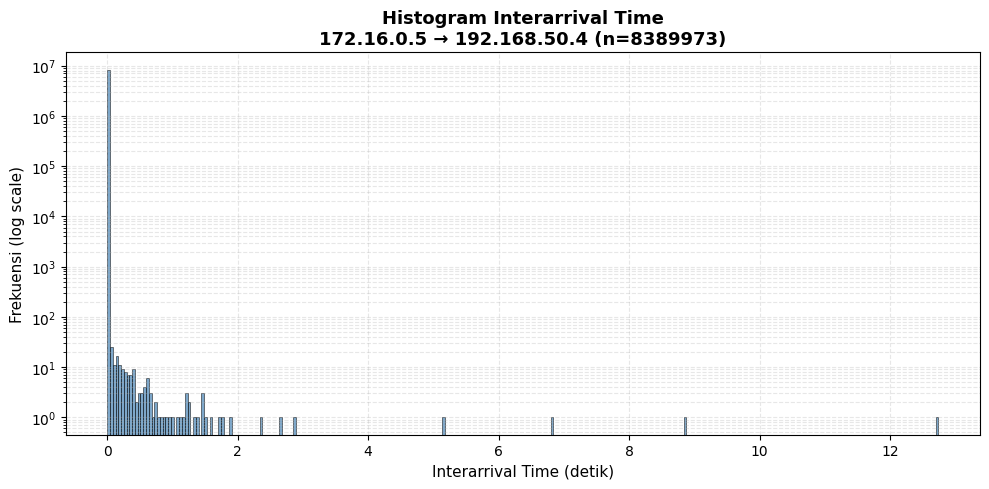

In [11]:
# Parameter visualisasi
bins = 300

# Loop tiap pasangan
for _, row in top_pair.iterrows():
    src = row['Source']
    dst = row['Destination']

    mask = (
        (df_ldap['Source'] == src) &
        (df_ldap['Destination'] == dst)
    )

    # Ambil kolom interarrival (aman untuk dua kemungkinan nama)
    if 'Interarrival' in df_ldap.columns:
        data = df_ldap.loc[mask, 'Interarrival'].values
    else:
        data = df_ldap_top.loc[
            (df_ldap_top['Source'] == src) &
            (df_ldap_top['Destination'] == dst),
            'Interarrival'
        ].dropna().to_numpy()

    # Tidak ada pembatasan rentang - gunakan semua data
    print(f"{src} → {dst} | n = {len(data)}")
    print(f"  Min: {np.min(data):.6f} | Max: {np.max(data):.6f} | Mean: {np.mean(data):.6f}")

    # Plot Histogram
    plt.figure(figsize=(10, 5))
    
    # Buat histogram dengan bar
    counts, bins_edges, patches = plt.hist(
        data, 
        bins=bins, 
        color='steelblue',      # Warna bar
        alpha=0.7,              # Transparansi
        edgecolor='black',      # Warna garis tepi bar
        linewidth=0.5           # Ketebalan garis tepi
    )

    # Tambahkan margin di kiri dan kanan (5-10% dari range data)
    data_min = np.min(data)
    data_max = np.max(data)
    data_range = data_max - data_min
    margin = data_range * 0.05  # 5% margin di kiri dan kanan
    
    plt.xlim(data_min - margin, data_max + margin)  # ← TAMBAHKAN MARGIN
    plt.yscale('log')  # Y-axis dalam skala logaritmik

    plt.xlabel('Interarrival Time (detik)', fontsize=11)
    plt.ylabel('Frekuensi (log scale)', fontsize=11)
    plt.title(
        f'Histogram Interarrival Time\n{src} → {dst} (n={len(data)})',
        fontsize=13,
        fontweight='bold'
    )

    plt.grid(True, which='both', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [12]:
# Ambil kolom interarrival
data = df_ldap_top.loc[
    (df_ldap_top['Source'] == '172.16.0.5') &
    (df_ldap_top['Destination'] == '192.168.50.4'),
    'Interarrival'
].dropna()

# Buang nilai nol / negatif (jika ada)
data = data[data > 0]

# HAPUS OUTLIER (< 0.6 detik)
data_clean = data[data < 0.6]


--------------------------------------------------
📊 PERBANDINGAN STATISTIK: SEBELUM vs SESUDAH CLEANING
--------------------------------------------------


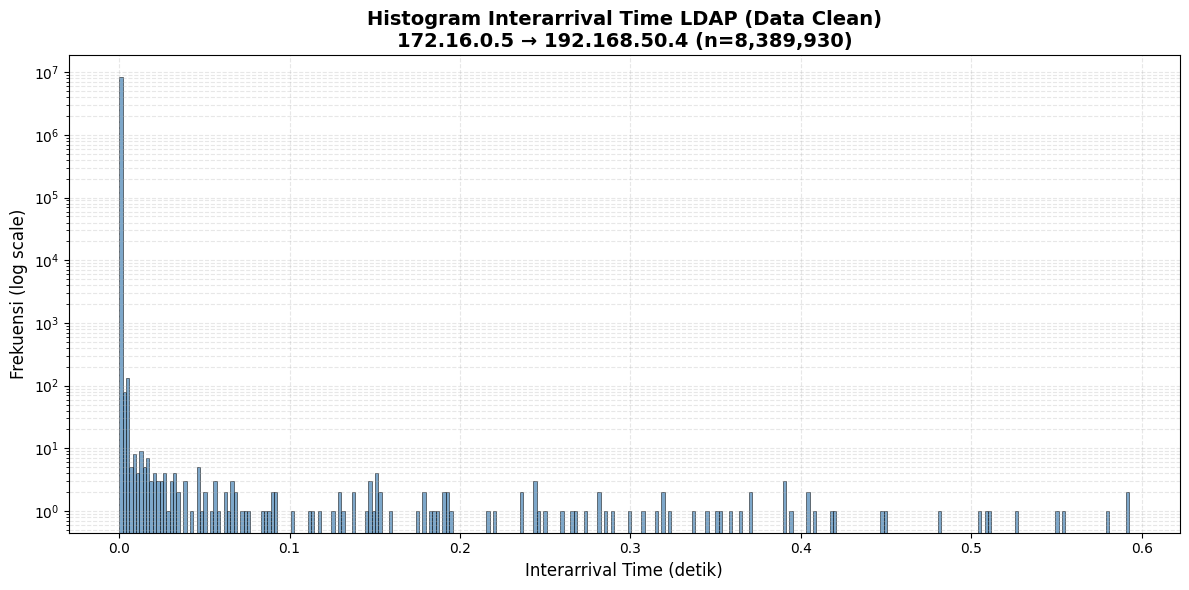

     Metrik  Sebelum_Cleaning  Sesudah_Cleaning  Selisih  Selisih_Persen (%)
Jumlah Data    8389930.000000    8389930.000000 0.000000            0.000000
        Min          0.000001          0.000001 0.000000            0.000000
        Max          0.592788          0.592788 0.000000            0.000000
       Mean          0.000060          0.000060 0.000000            0.000000
     Median          0.000001          0.000001 0.000000            0.000000
    Std Dev          0.001012          0.001012 0.000000            0.000000
   Q1 (25%)          0.000001          0.000001 0.000000            0.000000
   Q3 (75%)          0.000048          0.000048 0.000000            0.000000

--------------------------------------------------
Data dihapus: 0 (0.00%)
Data tersisa: 8,389,930 (100.00%)
--------------------------------------------------



In [39]:
# STATISTIK SEBELUM DAN SESUDAH CLEANING
# Asumsikan variabel 'data' adalah data sebelum cleaning
# dan 'data_clean' adalah data setelah cleaning

stats_comparison = pd.DataFrame({
    'Metrik': ['Jumlah Data', 'Min', 'Max', 'Mean', 'Median', 'Std Dev', 'Q1 (25%)', 'Q3 (75%)'],
    'Sebelum_Cleaning': [
        len(data),
        np.min(data),
        np.max(data),
        np.mean(data),
        np.median(data),
        np.std(data),
        np.percentile(data, 25),
        np.percentile(data, 75)
    ],
    'Sesudah_Cleaning': [
        len(data_clean),
        np.min(data_clean),
        np.max(data_clean),
        np.mean(data_clean),
        np.median(data_clean),
        np.std(data_clean),
        np.percentile(data_clean, 25),
        np.percentile(data_clean, 75)
    ]
})

print("\n" + "-"*50)
print("📊 PERBANDINGAN STATISTIK: SEBELUM vs SESUDAH CLEANING")
print("-"*50)

# HISTOGRAM DATA CLEAN
bins = 300
MARGIN_PERCENT = 0.05

plt.figure(figsize=(12, 6))

# Buat histogram
counts, bins_edges, patches = plt.hist(
    data_clean, 
    bins=bins, 
    color='steelblue',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Hitung margin
data_min = data_clean.min()
data_max = data_clean.max()
data_range = data_max - data_min
margin = data_range * MARGIN_PERCENT

# Set xlim dengan margin
plt.xlim(data_min - margin, data_max + margin)
plt.yscale('log')  # Y-axis dalam skala logaritmik

plt.xlabel('Interarrival Time (detik)', fontsize=12)
plt.ylabel('Frekuensi (log scale)', fontsize=12)
plt.title(
    f'Histogram Interarrival Time LDAP (Data Clean)\n172.16.0.5 → 192.168.50.4 (n={len(data_clean):,})',
    fontsize=14,
    fontweight='bold'
)

plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# HITUNG SELISIH
stats_comparison['Selisih'] = stats_comparison['Sebelum_Cleaning'] - stats_comparison['Sesudah_Cleaning']
stats_comparison['Selisih_Persen (%)'] = (stats_comparison['Selisih'] / stats_comparison['Sebelum_Cleaning']) * 100

# Tampilkan tabel perbandingan
pd.set_option('display.float_format', '{:.6f}'.format)
print(stats_comparison.to_string(index=False))

print("\n" + "-"*50)
print(f"Data dihapus: {len(data) - len(data_clean):,} ({((len(data) - len(data_clean))/len(data)*100):.2f}%)")
print(f"Data tersisa: {len(data_clean):,} ({(len(data_clean)/len(data)*100):.2f}%)")
print("-"*50 + "\n")

In [14]:
df_interarrival_clean = pd.DataFrame({
    'Source': '172.16.0.5',
    'Destination': '192.168.50.4',
    'Interarrival_clean': data_clean.values
})

df_interarrival_clean = df_interarrival_clean.reset_index(drop=True)

display(df_interarrival_clean)

,Source,Destination,Interarrival_clean
0,172.16.0.5,192.168.50.4,0.000003
1,172.16.0.5,192.168.50.4,0.504009
2,172.16.0.5,192.168.50.4,0.000003
3,172.16.0.5,192.168.50.4,0.192519
4,172.16.0.5,192.168.50.4,0.000003
...,...,...,...
8389925,172.16.0.5,192.168.50.4,0.091371
8389926,172.16.0.5,192.168.50.4,0.000003
8389927,172.16.0.5,192.168.50.4,0.000003
8389928,172.16.0.5,192.168.50.4,0.000001


### fungsi chi-square

In [15]:
def chi_square_test_continuous(data, dist, params, bins=50):
    observed, bin_edges = np.histogram(data, bins=bins)
    
    # Probabilitas teoritis tiap bin berdasarkan CDF
    cdf_values = dist.cdf(bin_edges, *params)
    expected_prob = np.diff(cdf_values)
    
    # Expected frequency
    expected = expected_prob * len(data)
    
    # Hindari expected yang terlalu kecil
    mask = expected > 5
    observed = observed[mask]
    expected = expected[mask]
    
    # Samakan total observed dan expected
    expected = expected * (observed.sum() / expected.sum())
    
    chi_stat, chi_p = chisquare(f_obs=observed, f_exp=expected)
    
    return chi_stat, chi_p

## Fitting distribusi

In [ ]:
def fit_distribution(data, dist, name, src, dst, n):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    # Jumlah data aktual
    n = len(data)

    # Jika data kosong, hentikan
    if n == 0:
        raise ValueError(f"Data kosong untuk {src} -> {dst} pada distribusi {name}")

    # FITTING DISTRIBUSI
    # Untuk interarrival time, loc lebih aman dikunci ke 0
    params = dist.fit(data, floc=0)
    k = len(params)

    # KS TEST
    ks_stat, ks_p = kstest(data, dist.name, args=params)

    # LOG-LIKELIHOOD
    logpdf_values = dist.logpdf(data, *params)
    logpdf_values = logpdf_values[np.isfinite(logpdf_values)]
    logL = np.sum(logpdf_values)

    # AIC & BIC
    aic = 2 * k - 2 * logL
    bic = k * np.log(n) - 2 * logL

    # CHI-SQUARE
    chi_stat, chi_p = chi_square_test_continuous(data, dist, params)

    # Parameter handling
    if name == 'Exponential':
        shape_param = np.nan
        loc_param = params[0]
        scale_param = params[1]
    else:
        shape_param = params[0]
        loc_param = params[1]
        scale_param = params[2]

    return {
        'Source': src,
        'Destination': dst,
        'Distribution': name,
        'shape': shape_param,
        'loc': loc_param,
        'scale': scale_param,
        'KS_statistic': ks_stat,
        'KS_pvalue': ks_p,
        'ChiSquare_statistic': chi_stat,
        'ChiSquare_pvalue': chi_p,
        'LogLikelihood': logL,
        'AIC': aic,
        'BIC': bic,
        'Type': 'Continuous'
    }

### perhitungan distribusi dan metrik

- distribusi weibull
- distribusi eksponensial
- distribusi lognormal
- distribusi gamma

In [17]:
# Cari pasangan (berdasarkan data CLEAN)
top_pair_clean = (
    df_interarrival_clean
    .groupby(['Source', 'Destination'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
    .head(1)
)

print("pasangan (berdasarkan data clean):")
display(top_pair_clean)

pasangan (berdasarkan data clean):


,Source,Destination,Count
0,172.16.0.5,192.168.50.4,8389930


1. distribusi weibull

In [18]:
results_weibull = []

for _, row in top_pair_clean.iterrows():
    src, dst = row['Source'], row['Destination']

    data = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data = data[data > 0]
    n = len(data)

    try:
        res = fit_distribution(data, weibull_min, 'Weibull', src, dst, n)
        results_weibull.append(res)
    except Exception as e:
        print(f"Weibull gagal: {e}")

df_weibull = pd.DataFrame(results_weibull)

2. distribusi eksponensial

In [19]:
results_exponential = []

for _, row in top_pair_clean.iterrows():
    src, dst = row['Source'], row['Destination']

    data = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data = data[data > 0]
    n = len(data)

    try:
        res = fit_distribution(data, expon, 'Exponential', src, dst, n)
        results_exponential.append(res)
    except Exception as e:
        print(f"Exponential gagal: {e}")

df_exponential = pd.DataFrame(results_exponential)

3. distribusi lognormal

In [20]:
results_lognormal = []

for _, row in top_pair_clean.iterrows():
    src, dst = row['Source'], row['Destination']

    data = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data = data[data > 0]
    n = len(data)

    try:
        res = fit_distribution(data, lognorm, 'Lognormal', src, dst, n)
        results_lognormal.append(res)
    except Exception as e:
        print(f"Lognormal gagal: {e}")

df_lognormal = pd.DataFrame(results_lognormal)

4. distribusi gamma

In [21]:
results_gamma = []

for _, row in top_pair_clean.iterrows():
    src, dst = row['Source'], row['Destination']

    data = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data = data[data > 0]
    n = len(data)

    try:
        res = fit_distribution(data, gamma_dist, 'Gamma', src, dst, n)
        results_gamma.append(res)
    except Exception as e:
        print(f"Gamma gagal: {e}")

df_gamma = pd.DataFrame(results_gamma)

In [22]:
df_results = pd.concat([
    df_weibull,
    df_lognormal,
    df_exponential,
    df_gamma
], ignore_index=True)
df_results

,Source,Destination,Distribution,shape,loc,scale,KS_statistic,KS_pvalue,ChiSquare_statistic,ChiSquare_pvalue,LogLikelihood,AIC,BIC,Type
0,172.16.0.5,192.168.50.4,Weibull,0.433706,0.000000,0.000020,0.319899,0.000000,0.000000,NaN,81191307.782270,-162382609.564540,-162382567.736912,Continuous
1,172.16.0.5,192.168.50.4,Lognormal,2.264966,0.000000,0.000006,0.344821,0.000000,4045.424797,0.000000,82169772.077984,-164339538.155967,-164339496.328339,Continuous
2,172.16.0.5,192.168.50.4,Exponential,NaN,0.000000,0.000060,0.584196,0.000000,0.000000,NaN,73207701.496029,-146415398.992058,-146415371.106973,Continuous
3,172.16.0.5,192.168.50.4,Gamma,0.299313,0.000000,0.000200,0.336847,0.000000,0.000000,NaN,80391970.626890,-160783935.253780,-160783893.426151,Continuous


In [23]:
df_rank = df_results.copy()

# Pastikan nilai inf diganti NaN agar tidak mengganggu ranking
df_rank = df_rank.replace([np.inf, -np.inf], np.nan)

# Ranking: semakin kecil nilai metrik, semakin baik
df_rank['Rank_AIC'] = df_rank.groupby(['Source', 'Destination'])['AIC'].rank(method='min', ascending=True)
df_rank['Rank_BIC'] = df_rank.groupby(['Source', 'Destination'])['BIC'].rank(method='min', ascending=True)
df_rank['Rank_KS'] = df_rank.groupby(['Source', 'Destination'])['KS_statistic'].rank(method='min', ascending=True)
df_rank['Rank_ChiSquare'] = df_rank.groupby(['Source', 'Destination'])['ChiSquare_statistic'].rank(method='min', ascending=True)

# Total ranking
df_rank['Total_Rank'] = (
    df_rank['Rank_AIC'] +
    df_rank['Rank_BIC'] +
    df_rank['Rank_KS'] +
    df_rank['Rank_ChiSquare']
)

# Pilih distribusi dengan total rank terkecil
best_dist = df_rank.loc[
    df_rank.groupby(['Source', 'Destination'])['Total_Rank'].idxmin()
]

display(
    best_dist[
        [
            'Source',
            'Destination',
            'Distribution',
            'AIC',
            'BIC',
            'KS_statistic',
            'ChiSquare_statistic',
            'Total_Rank'
        ]
    ]
)

,Source,Destination,Distribution,AIC,BIC,KS_statistic,ChiSquare_statistic,Total_Rank
0,172.16.0.5,192.168.50.4,Weibull,-162382609.564540,-162382567.736912,0.319899,0.000000,6.000000


## Generate data distribusi

### Generate data distribusi weibull

In [24]:
np.random.seed(42)

synthetic_weibull = []

for _, row in df_results[df_results['Distribution'] == 'Weibull'].iterrows():

    src = row['Source']
    dst = row['Destination']

    shape = row['shape']
    loc = row['loc']
    scale = row['scale']

    data_asli = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data_asli = data_asli[np.isfinite(data_asli)]
    data_asli = data_asli[data_asli > 0]

    n = len(data_asli)

    if n == 0:
        continue

    # Generate sampai jumlah data sintesis sama dengan data asli
    synth_list = []

    while len(synth_list) < n:
        synth = weibull_min.rvs(
            shape,
            loc=loc,
            scale=scale,
            size=n
        )

        synth = synth[np.isfinite(synth)]
        synth = synth[synth > 0]

        synth_list.extend(synth)

    synth = np.array(synth_list[:n])

    df_temp = pd.DataFrame({
        'Source': src,
        'Destination': dst,
        'Distribution': 'Weibull',
        'Interarrival_Synthetic': synth
    })

    synthetic_weibull.append(df_temp)

df_weibull = pd.concat(synthetic_weibull, ignore_index=True)

df_weibull.to_csv(
    "synthetic_weibull.csv",
    index=False
)

print(df_weibull.head())
print("Jumlah data sintesis:", len(df_weibull))

       Source   Destination Distribution  Interarrival_Synthetic
0  172.16.0.5  192.168.50.4      Weibull                0.000003
1  172.16.0.5  192.168.50.4      Weibull                0.000250
2  172.16.0.5  192.168.50.4      Weibull                0.000037
3  172.16.0.5  192.168.50.4      Weibull                0.000016
4  172.16.0.5  192.168.50.4      Weibull                0.000000
Jumlah data sintesis: 8389930


### Generate data distribusi lognormal

In [25]:
np.random.seed(42)

synthetic_lognormal = []

for _, row in df_results[df_results['Distribution'] == 'Lognormal'].iterrows():

    src = row['Source']
    dst = row['Destination']

    shape = row['shape']
    loc = row['loc']
    scale = row['scale']

    data_asli = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data_asli = data_asli[np.isfinite(data_asli)]
    data_asli = data_asli[data_asli > 0]

    n = len(data_asli)

    if n == 0:
        continue

    # Generate sampai jumlah data sintesis sama dengan data asli
    synth_list = []

    while len(synth_list) < n:
        synth = lognorm.rvs(
            shape,
            loc=loc,
            scale=scale,
            size=n
        )

        synth = synth[np.isfinite(synth)]
        synth = synth[synth > 0]

        synth_list.extend(synth)

    synth = np.array(synth_list[:n])

    df_temp = pd.DataFrame({
        'Source': src,
        'Destination': dst,
        'Distribution': 'Lognormal',
        'Interarrival_Synthetic': synth
    })

    synthetic_lognormal.append(df_temp)

df_lognormal = pd.concat(
    synthetic_lognormal,
    ignore_index=True
)

df_lognormal.to_csv(
    "synthetic_lognormal.csv",
    index=False
)

print(df_lognormal.head())
print("Jumlah data sintesis Lognormal:", len(df_lognormal))

       Source   Destination Distribution  Interarrival_Synthetic
0  172.16.0.5  192.168.50.4    Lognormal                0.000018
1  172.16.0.5  192.168.50.4    Lognormal                0.000004
2  172.16.0.5  192.168.50.4    Lognormal                0.000026
3  172.16.0.5  192.168.50.4    Lognormal                0.000188
4  172.16.0.5  192.168.50.4    Lognormal                0.000004
Jumlah data sintesis Lognormal: 8389930


### Generate data distribusi exponential

In [26]:
np.random.seed(42)

synthetic_exponential = []

for _, row in df_results[df_results['Distribution'] == 'Exponential'].iterrows():

    src = row['Source']
    dst = row['Destination']

    loc = row['loc']
    scale = row['scale']

    data_asli = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data_asli = data_asli[np.isfinite(data_asli)]
    data_asli = data_asli[data_asli > 0]

    n = len(data_asli)

    if n == 0:
        continue

    # Generate sampai jumlah data sintesis sama dengan data asli
    synth_list = []

    while len(synth_list) < n:
        synth = expon.rvs(
            loc=loc,
            scale=scale,
            size=n
        )

        synth = synth[np.isfinite(synth)]
        synth = synth[synth > 0]

        synth_list.extend(synth)

    synth = np.array(synth_list[:n])

    df_temp = pd.DataFrame({
        'Source': src,
        'Destination': dst,
        'Distribution': 'Exponential',
        'Interarrival_Synthetic': synth
    })

    synthetic_exponential.append(df_temp)

df_exponential = pd.concat(
    synthetic_exponential,
    ignore_index=True
)

df_exponential.to_csv(
    "synthetic_exponential.csv",
    index=False
)

print(df_exponential.head())
print("Jumlah data sintesis Exponential:", len(df_exponential))

       Source   Destination Distribution  Interarrival_Synthetic
0  172.16.0.5  192.168.50.4  Exponential                0.000028
1  172.16.0.5  192.168.50.4  Exponential                0.000180
2  172.16.0.5  192.168.50.4  Exponential                0.000079
3  172.16.0.5  192.168.50.4  Exponential                0.000055
4  172.16.0.5  192.168.50.4  Exponential                0.000010
Jumlah data sintesis Exponential: 8389930


### Generate data distribusi Gamma

In [27]:
np.random.seed(42)

synthetic_gamma = []

for _, row in df_results[df_results['Distribution'] == 'Gamma'].iterrows():

    src = row['Source']
    dst = row['Destination']

    shape = row['shape']
    loc = row['loc']
    scale = row['scale']

    data_asli = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    # Bersihkan data asli
    data_asli = data_asli[np.isfinite(data_asli)]
    data_asli = data_asli[data_asli > 0]

    n = len(data_asli)

    if n == 0:
        continue

    # Generate sampai jumlah data sintesis sama dengan data asli
    synth_list = []

    while len(synth_list) < n:
        synth = gamma_dist.rvs(
            shape,
            loc=loc,
            scale=scale,
            size=n
        )

        # Bersihkan hasil generate
        synth = synth[np.isfinite(synth)]
        synth = synth[synth > 0]

        synth_list.extend(synth)

    synth = np.array(synth_list[:n])

    df_temp = pd.DataFrame({
        'Source': src,
        'Destination': dst,
        'Distribution': 'Gamma',
        'Interarrival_Synthetic': synth
    })

    synthetic_gamma.append(df_temp)

df_gamma = pd.concat(
    synthetic_gamma,
    ignore_index=True
)

df_gamma.to_csv(
    "synthetic_gamma.csv",
    index=False
)

print(df_gamma.head())
print("Jumlah data sintesis Gamma:", len(df_gamma))

       Source   Destination Distribution  Interarrival_Synthetic
0  172.16.0.5  192.168.50.4        Gamma                0.000008
1  172.16.0.5  192.168.50.4        Gamma                0.000071
2  172.16.0.5  192.168.50.4        Gamma                0.000000
3  172.16.0.5  192.168.50.4        Gamma                0.000000
4  172.16.0.5  192.168.50.4        Gamma                0.000036
Jumlah data sintesis Gamma: 8389930


## Perbandingan statistik data sintesis dengan data asli

In [28]:
def statistik_deskriptif(data, nama_data):
    data = data[np.isfinite(data)]
    data = data[data > 0]

    return {
        'Data': nama_data,
        'Jumlah Data': len(data),
        'Mean': np.mean(data),
        'Median': np.median(data),
        'Std': np.std(data),
        'Min': np.min(data),
        'Q1 / 25%': np.percentile(data, 25),
        'Q3 / 75%': np.percentile(data, 75),
        'P90': np.percentile(data, 90),
        'P95': np.percentile(data, 95),
        'P99': np.percentile(data, 99),
        'P99.9': np.percentile(data, 99.9),
        'Max': np.max(data)
    }


stats_perbandingan = pd.DataFrame([
    statistik_deskriptif(
        df_interarrival_clean['Interarrival_clean'].values,
        'Data Asli'
    ),
    statistik_deskriptif(
        df_weibull['Interarrival_Synthetic'].values,
        'Sintesis Weibull'
    ),
    statistik_deskriptif(
        df_lognormal['Interarrival_Synthetic'].values,
        'Sintesis Lognormal'
    ),
    statistik_deskriptif(
        df_exponential['Interarrival_Synthetic'].values,
        'Sintesis Exponential'
    ),
    statistik_deskriptif(
        df_gamma['Interarrival_Synthetic'].values,
        'Sintesis Gamma'
    )
])

display(stats_perbandingan)

,Data,Jumlah Data,Mean,Median,Std,Min,Q1 / 25%,Q3 / 75%,P90,P95,P99,P99.9,Max
0,Data Asli,8389930,0.000060,0.000001,0.001012,0.000001,0.000001,0.000048,0.000201,0.000360,0.000460,0.000704,0.592788
1,Sintesis Weibull,8389930,0.000053,0.000008,0.000146,0.000000,0.000001,0.000042,0.000134,0.000247,0.000665,0.001687,0.012263
2,Sintesis Lognormal,8389930,0.000078,0.000006,0.000947,0.000000,0.000001,0.000027,0.000109,0.000248,0.001158,0.006492,0.812913
3,Sintesis Exponential,8389930,0.000060,0.000041,0.000060,0.000000,0.000017,0.000083,0.000137,0.000179,0.000275,0.000412,0.000974
4,Sintesis Gamma,8389930,0.000060,0.000015,0.000109,0.000000,0.000001,0.000068,0.000176,0.000273,0.000527,0.000923,0.002722


In [29]:
def calculate_similarity_metrics(data_asli, data_sintesis):
    data_asli = np.asarray(data_asli, dtype=float)
    data_sintesis = np.asarray(data_sintesis, dtype=float)

    data_asli = data_asli[np.isfinite(data_asli)]
    data_sintesis = data_sintesis[np.isfinite(data_sintesis)]

    data_asli = data_asli[data_asli > 0]
    data_sintesis = data_sintesis[data_sintesis > 0]

    # 1. KS 2-sample
    ks_stat, ks_pvalue = ks_2samp(data_asli, data_sintesis)
    ks_similarity = (1 - ks_stat) * 100

    # 2. Wasserstein Distance
    w_dist = wasserstein_distance(data_asli, data_sintesis)

    # Normalisasi pakai IQR agar tidak terlalu sensitif terhadap outlier
    iqr = np.percentile(data_asli, 75) - np.percentile(data_asli, 25)
    scale_ref = iqr if iqr > 0 else np.std(data_asli)

    w_norm = w_dist / scale_ref if scale_ref > 0 else 0
    w_similarity = (1 / (1 + w_norm)) * 100

    # 3. Jensen-Shannon
    bins = np.histogram_bin_edges(
        np.concatenate([data_asli, data_sintesis]),
        bins=50
    )

    hist_a, _ = np.histogram(data_asli, bins=bins, density=False)
    hist_s, _ = np.histogram(data_sintesis, bins=bins, density=False)

    hist_a = hist_a / (hist_a.sum() + 1e-10)
    hist_s = hist_s / (hist_s.sum() + 1e-10)

    js_div = jensenshannon(hist_a, hist_s)
    js_similarity = (1 - js_div) * 100

    # 4. Statistik dasar
    stats_a = np.array([
        np.mean(data_asli),
        np.std(data_asli),
        np.median(data_asli),
        np.percentile(data_asli, 25),
        np.percentile(data_asli, 75)
    ])

    stats_s = np.array([
        np.mean(data_sintesis),
        np.std(data_sintesis),
        np.median(data_sintesis),
        np.percentile(data_sintesis, 25),
        np.percentile(data_sintesis, 75)
    ])

    smape = np.mean(
        np.abs(stats_a - stats_s) /
        ((np.abs(stats_a) + np.abs(stats_s)) / 2 + 1e-10)
    )

    stats_similarity = (1 - min(smape, 1)) * 100

    # 5. Overall similarity
    overall = (
        0.25 * ks_similarity +
        0.25 * w_similarity +
        0.25 * js_similarity +
        0.25 * stats_similarity
    )

    return {
        'KS_similarity': ks_similarity,
        'Wasserstein_similarity': w_similarity,
        'JS_similarity': js_similarity,
        'Stats_similarity': stats_similarity,
        'Overall_similarity': overall,
        'KS_pvalue': ks_pvalue,
        'KS_statistic': ks_stat,
        'Wasserstein_distance': w_dist,
        'JS_divergence': js_div,
        'SMAPE_stats': smape
    }


# Gabungkan semua data sintesis
df_synthetic_all = pd.concat(
    [df_weibull, df_lognormal, df_exponential, df_gamma],
    ignore_index=True
)

evaluation_results = []

pairs = df_interarrival_clean[['Source', 'Destination']].drop_duplicates()

for _, pair in pairs.iterrows():
    src = pair['Source']
    dst = pair['Destination']

    data_asli = df_interarrival_clean.loc[
        (df_interarrival_clean['Source'] == src) &
        (df_interarrival_clean['Destination'] == dst),
        'Interarrival_clean'
    ].values

    data_asli = data_asli[np.isfinite(data_asli)]
    data_asli = data_asli[data_asli > 0]

    if len(data_asli) == 0:
        continue

    for dist_name in ['Weibull', 'Lognormal', 'Exponential', 'Gamma']:
        data_sintesis = df_synthetic_all.loc[
            (df_synthetic_all['Source'] == src) &
            (df_synthetic_all['Destination'] == dst) &
            (df_synthetic_all['Distribution'] == dist_name),
            'Interarrival_Synthetic'
        ].values

        data_sintesis = data_sintesis[np.isfinite(data_sintesis)]
        data_sintesis = data_sintesis[data_sintesis > 0]

        if len(data_sintesis) == 0:
            continue

        sim = calculate_similarity_metrics(data_asli, data_sintesis)

        sim['Source'] = src
        sim['Destination'] = dst
        sim['Distribution'] = dist_name
        sim['n_asli'] = len(data_asli)
        sim['n_sintesis'] = len(data_sintesis)

        evaluation_results.append(sim)

df_evaluation = pd.DataFrame(evaluation_results)

display(df_evaluation)

,KS_similarity,Wasserstein_similarity,JS_similarity,Stats_similarity,Overall_similarity,KS_pvalue,KS_statistic,Wasserstein_distance,JS_divergence,SMAPE_stats,Source,Destination,Distribution,n_asli,n_sintesis
0,68.004310,65.763420,99.740848,31.259089,66.191917,0.000000,0.319957,0.000024,0.002592,0.687409,172.16.0.5,192.168.50.4,Weibull,8389930,8389930
1,65.538604,47.157075,99.166215,48.971589,65.208371,0.000000,0.344614,0.000053,0.008338,0.510284,172.16.0.5,192.168.50.4,Lognormal,8389930,8389930
2,41.582540,52.741060,99.736564,0.000000,48.515041,0.000000,0.584175,0.000042,0.002634,1.198998,172.16.0.5,192.168.50.4,Exponential,8389930,8389930
3,66.308503,71.953038,99.736564,19.847513,64.461404,0.000000,0.336915,0.000018,0.002634,0.801525,172.16.0.5,192.168.50.4,Gamma,8389930,8389930


# Histogram perbandingan data sintesis dengan data asli

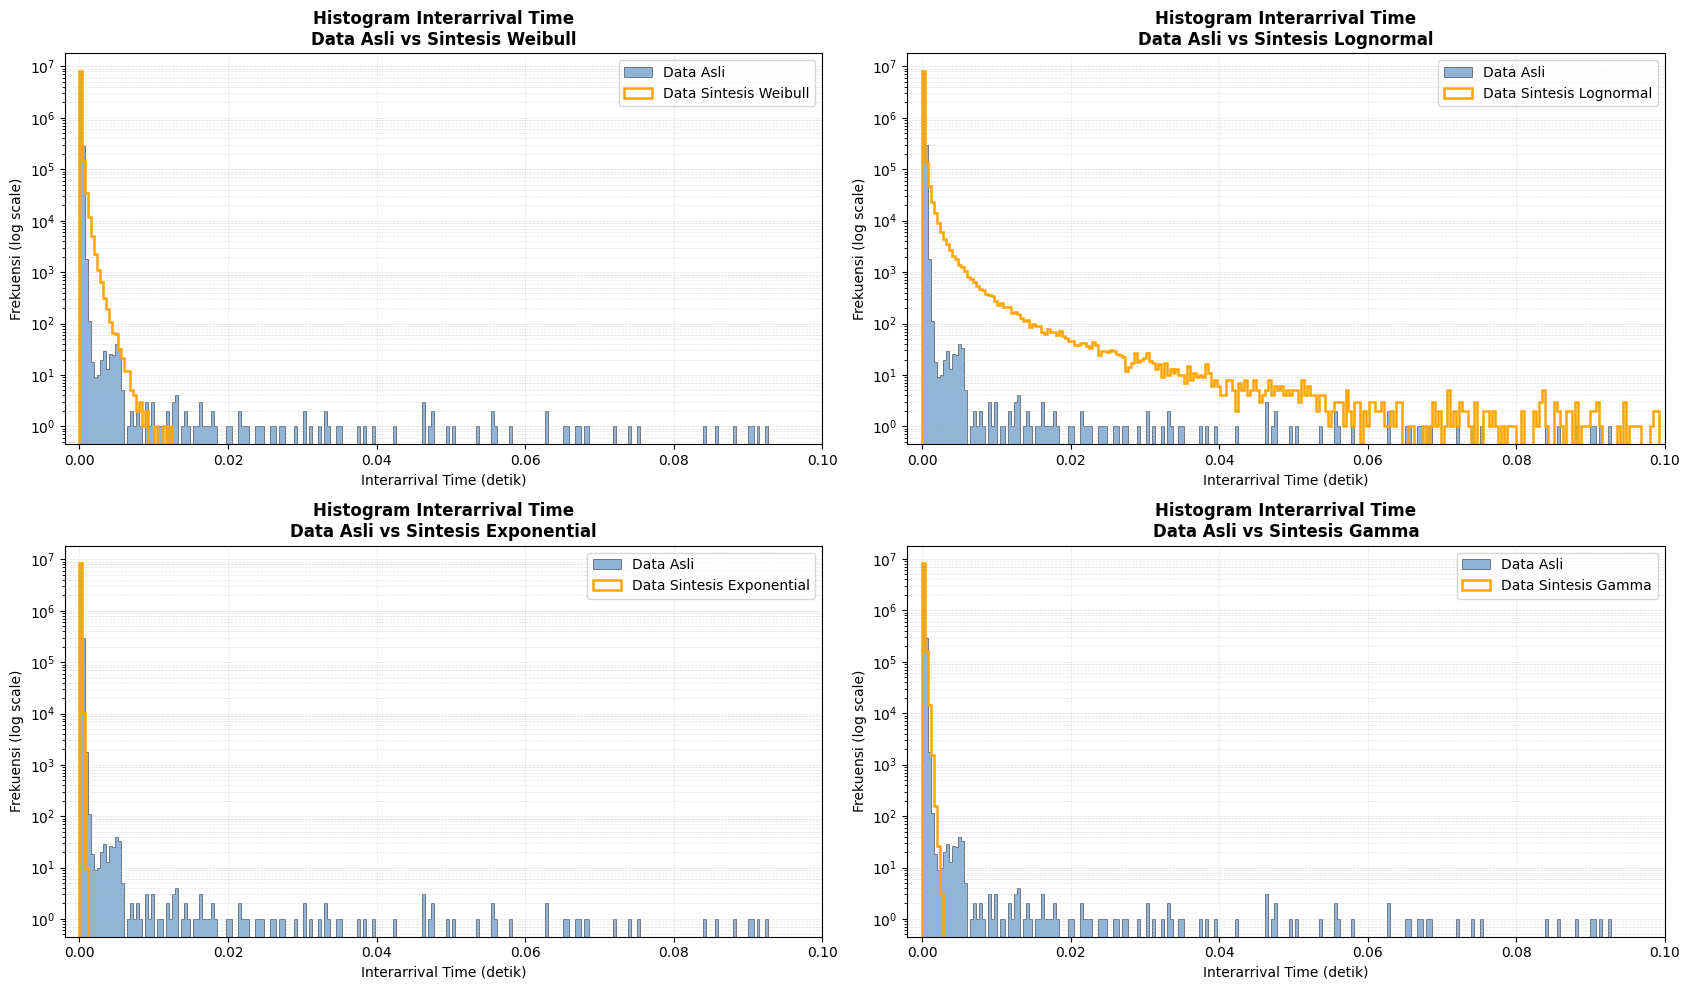

In [30]:
# 1. AMBIL DATA ASLI
data_asli = df_interarrival_clean['Interarrival_clean'].dropna().values
data_asli = np.asarray(data_asli, dtype=float)
data_asli = data_asli[np.isfinite(data_asli)]
data_asli = data_asli[data_asli > 0]

# 2. SIAPKAN DATA SINTESIS
synthetic_data = {
    'Weibull': df_weibull['Interarrival_Synthetic'].dropna().values,
    'Lognormal': df_lognormal['Interarrival_Synthetic'].dropna().values,
    'Exponential': df_exponential['Interarrival_Synthetic'].dropna().values,
    'Gamma': df_gamma['Interarrival_Synthetic'].dropna().values
}

for dist_name in synthetic_data:
    x = np.asarray(synthetic_data[dist_name], dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    synthetic_data[dist_name] = x

# 3. PENGATURAN HISTOGRAM
x_min = 0
x_max = 0.1
x_left_margin = -0.002
bins = 250

bin_edges = np.linspace(x_min, x_max, bins)

# 4. HISTOGRAM OUTLINE DATA ASLI VS SINTESIS
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
axes = axes.flatten()

for ax, (dist_name, data_sintesis) in zip(axes, synthetic_data.items()):

    asli_plot = data_asli[(data_asli >= x_min) & (data_asli <= x_max)]
    sintesis_plot = data_sintesis[(data_sintesis >= x_min) & (data_sintesis <= x_max)]

    ax.hist(
        asli_plot,
        bins=bin_edges,
        histtype='stepfilled',
        alpha=0.45,
        label='Data Asli',
        color="#095BAC",
        edgecolor='black',
        linewidth=0.7
    )

    ax.hist(
        sintesis_plot,
        bins=bin_edges,
        histtype='step',
        label=f'Data Sintesis {dist_name}',
        color='#FFA500' ,
        linewidth=1.8
    )

    ax.set_yscale('log')
    ax.set_xlim(x_left_margin, x_max)

    ax.set_title(
        f'Histogram Interarrival Time\nData Asli vs Sintesis {dist_name}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Interarrival Time (detik)')
    ax.set_ylabel('Frekuensi (log scale)')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.show()

In [31]:
best_synthetic = df_evaluation.loc[
    df_evaluation.groupby(['Source', 'Destination'])['Overall_similarity'].idxmax()
][['Source', 'Destination', 'Distribution', 'Overall_similarity']]

print("\nDistribusi Terbaik per Pasangan")
print(best_synthetic.to_string(index=False))


Distribusi Terbaik per Pasangan
    Source  Destination Distribution  Overall_similarity
172.16.0.5 192.168.50.4      Weibull           66.191917


In [35]:
# read_data
csv_file_path = "D:\\KULIAH\\SKRIPSI AFI\\DES\\dataset\\CIC-DDoS2019\\LDAP\\synthetic_weibull.csv"
df_weibull_sintetis = pd.read_csv(csv_file_path)

In [36]:
df_weibull_sintetis.describe()

,Interarrival_Synthetic
count,8389930.000000
mean,0.000053
std,0.000146
min,0.000000
25%,0.000001
50%,0.000008
75%,0.000042
max,0.012263


In [37]:
df_arrival = []

for (src, dst), group in df_weibull_sintetis.groupby(['Source', 'Destination']):

    # Ambil interarrival
    interarrival = group['Interarrival_Synthetic'].values

    # Hitung arrival time (cumulative sum)
    arrival_time = np.cumsum(interarrival)

    # Optional: mulai dari 0
    arrival_time = np.insert(arrival_time[:-1], 0, 0)

    df_temp = pd.DataFrame({
        'Source': src,
        'Destination': dst,
        'Interarrival': interarrival,
        'Arrival_Time': arrival_time
    })

    df_arrival.append(df_temp)

df_arrival_time = pd.concat(df_arrival, ignore_index=True)

print(df_arrival_time.head())
df_arrival_time.describe()

       Source   Destination  Interarrival  Arrival_Time
0  172.16.0.5  192.168.50.4      0.000003      0.000000
1  172.16.0.5  192.168.50.4      0.000250      0.000003
2  172.16.0.5  192.168.50.4      0.000037      0.000253
3  172.16.0.5  192.168.50.4      0.000016      0.000290
4  172.16.0.5  192.168.50.4      0.000000      0.000306


,Interarrival,Arrival_Time
count,8389930.000000,8389930.000000
mean,0.000053,222.649966
std,0.000146,128.482172
min,0.000000,0.000000
25%,0.000001,111.412868
50%,0.000008,222.769338
75%,0.000042,333.921576
max,0.012263,445.078818


In [38]:
output_path = "arrival_time_synthetic_ldap.csv"

df_arrival_time.to_csv(output_path, index=False)